✅ Model path: E:\Projects\Blood_Group_new\Blood_group_new\CNN\best_basic_cnn_with_residual.pth
✅ Image path: E:\Projects\Blood_Group_new\Blood_group_new\CNN\Screenshot 2025-09-30 094702.bmp

🎯 Predicted Blood Group: O+ (83.34% confidence)



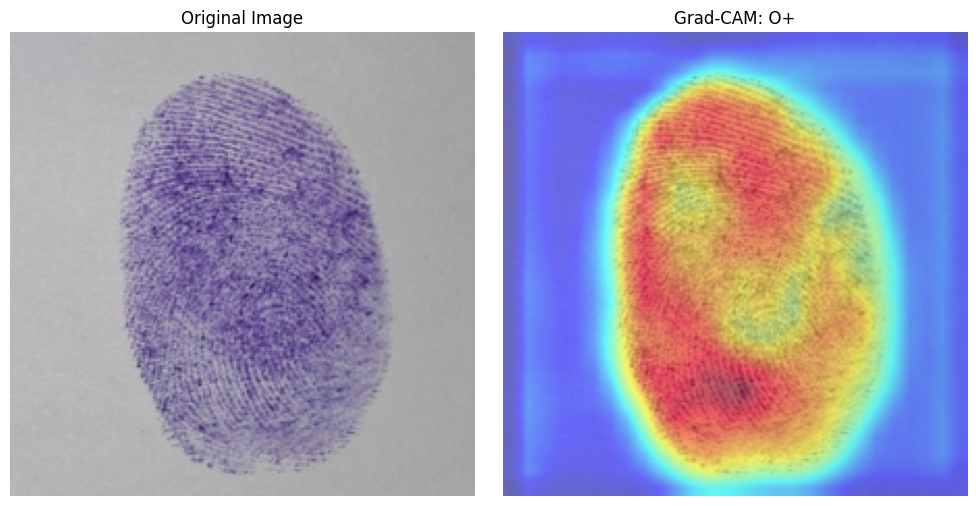

Grad-CAM heatmap saved as 'gradcam_O+.jpg'


In [1]:
# gradcam_residual_cnn.py

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================================================
# 🧩 Residual Block Definition
# ==========================================================
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        identity = x
        out = self.conv_block(x)
        out += identity
        return torch.relu(out)

# ==========================================================
# 🧠 BasicCNN with Residual Block
# ==========================================================
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            ResidualBlock(128),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ==========================================================
# ⚙️ CONFIGURATION
# ==========================================================
MODEL_PATH = r"E:\Projects\Blood_Group_new\Blood_group_new\CNN\best_basic_cnn_with_residual.pth"
IMAGE_PATH = r"E:\Projects\Blood_Group_new\Blood_group_new\CNN\Screenshot 2025-09-30 094702.bmp"
CLASS_NAMES = ["A-", "A+", "B-", "B+", "AB-", "AB+", "O-", "O+"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# ✅ Validate paths
# ==========================================================
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Model file not found: {MODEL_PATH}")
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"❌ Image file not found: {IMAGE_PATH}")

print(f"✅ Model path: {MODEL_PATH}")
print(f"✅ Image path: {IMAGE_PATH}")

# ==========================================================
# 🧠 Load Model
# ==========================================================
model = BasicCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# ==========================================================
# 🖼 Image Preprocessing
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)
    rgb_img = np.array(img.resize((224, 224))) / 255.0
    return input_tensor, rgb_img

input_tensor, rgb_img = load_image(IMAGE_PATH)

# ==========================================================
# 🔥 Grad-CAM Generation
# ==========================================================
target_layers = [model.features[-2]]  # last Conv2d layer

cam = GradCAM(model=model, target_layers=target_layers)

grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

# Clean up hooks
if hasattr(cam, "activations_and_grads"):
    cam.activations_and_grads.release()
del cam

cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# ==========================================================
# 🧠 Prediction
# ==========================================================
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    predicted_label = CLASS_NAMES[pred_idx]
    confidence = probs[0, pred_idx].item()

print(f"\n🎯 Predicted Blood Group: {predicted_label} ({confidence*100:.2f}% confidence)\n")

# ==========================================================
# 📊 Display & Save Results
# ==========================================================
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM: {predicted_label}")
plt.axis("off")

plt.tight_layout()

save_name = f"gradcam_{predicted_label}.jpg"
plt.savefig(save_name)
plt.show()

print(f"Grad-CAM heatmap saved as '{save_name}'")


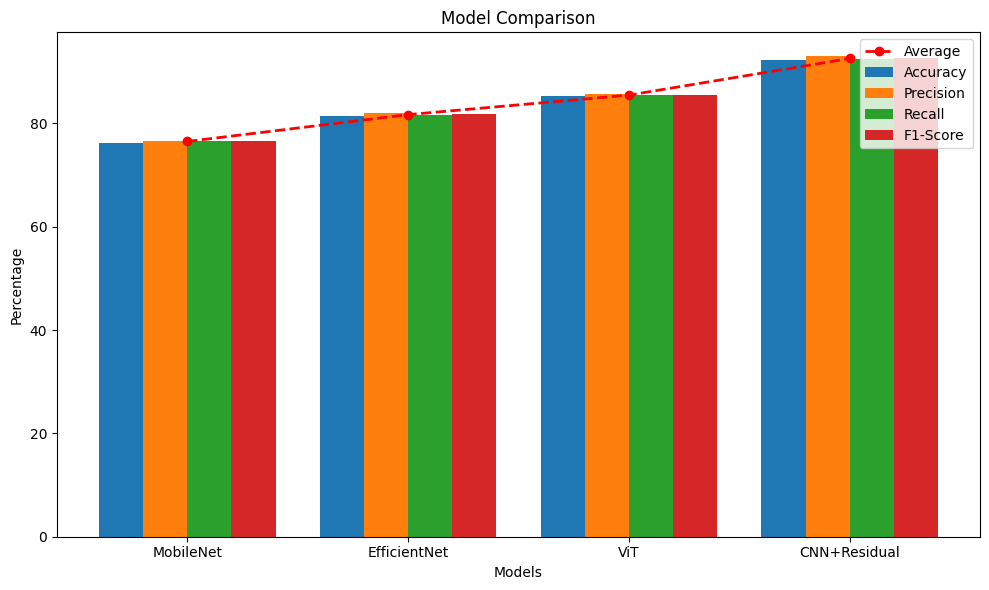

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Your data
data = {
    'Model': ['MobileNet', 'EfficientNet', 'ViT', 'CNN+Residual'],
    'Accuracy': [76.26, 81.39, 85.26, 92.26],
    'Precision': [76.62, 81.90, 85.65, 92.95],
    'Recall': [76.50, 81.67, 85.39, 92.36],
    'F1-Score': [76.54, 81.74, 85.50, 92.58]
}

df = pd.DataFrame(data)

# Calculate average metric per model
df['Average'] = df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean(axis=1)

# Set positions and width for bars
labels = df['Model']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
for i, metric in enumerate(metrics):
    ax.bar(x + i*width - width*1.5, df[metric], width, label=metric)

# Plot line for average
ax.plot(x, df['Average'], color='red', marker='o', linestyle='--', linewidth=2, label='Average')

# Add labels, title, legend
ax.set_xlabel('Models')
ax.set_ylabel('Percentage')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Save the figure
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
